In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
housing=fetch_california_housing()
df=pd.DataFrame(housing.data,columns=housing.feature_names)
df["MedHouseValue"]=housing.target
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  


In [11]:
X=df[["MedInc","HouseAge","AveRooms","AveOccup"]]
y=df["MedHouseValue"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)

In [14]:
model=LinearRegression()
model.fit(X_train,y_train)

print("coefficients",model.coef_)
print("intercept",model.intercept_)

coefficients [ 0.4454656   0.01690406 -0.02838069 -0.00414382]
intercept 0.026697367635456715


In [16]:
y_pred=model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test,
y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.657451727882265
R² Score: 0.49828508595474374


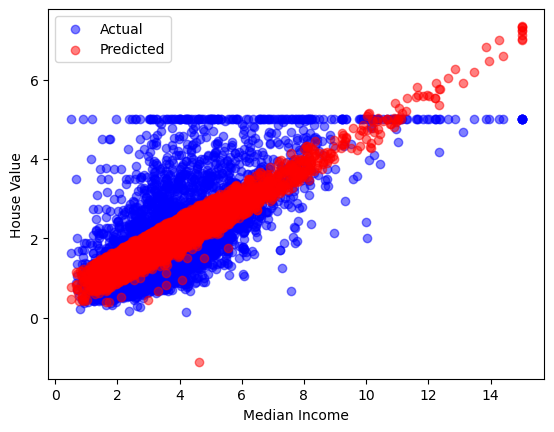

In [17]:
plt.scatter(X_test["MedInc"], y_test, color="blue",
alpha=0.5, label="Actual")
plt.scatter(X_test["MedInc"], y_pred, color="red",
alpha=0.5, label="Predicted")
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.legend()
plt.show()